# Compare Significant Terms

Analyzes significant terms driving model predictions.

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from tqdm import tqdm
import os
import json
import shutup; shutup.please()
dataset = "Analgesics-induced_acute_liver_failure"
dirpath = os.path.join(r'/home/hsdslab/Documents/Csabi/Pharma_crossval/DeepCausalPV-master-main/dat',dataset,'proc')

In [3]:
with open(os.path.join(dirpath, "all_sigterms.json"), "r") as f:
    results = json.load(f)

In [4]:
idx = '01'
res = results[idx]

In [5]:
res.keys()

dict_keys(['xgb', 'xgb_cal', 'biobert_temp', 'biobert_temp_cal', 'biobert_llm', 'biobert_llm_cal', 'albert_temp', 'albert_temp_cal', 'prr', 'ror', 'ebgm'])

In [6]:
model_names = ['xgb', 'xgb_cal', 'biobert_temp', 'biobert_temp_cal', 'biobert_llm',
       'biobert_llm_cal', 'albert_temp', 'albert_temp_cal']

def calc_jaccard(model):
    trad_methods = ['prr', 'ror', 'ebgm']
    
    jaccards = {}
    
    for method in trad_methods:
        jaccards[method] = []
        for idx in results.keys():
            intersection = set(results[idx][method]) & set(results[idx][model])
            union = set(results[idx][method]) | set(results[idx][model])
        
            jaccards[method].append(len(intersection) / len(union))
            
    # jaccard with all three traditional methods
    jaccards['all'] = []
    for idx in results.keys():
        intersection = set(results[idx]['prr']) & set(results[idx]['ror']) & set(results[idx]['ebgm']) & set(results[idx][model])
        union = set(results[idx]['prr']) | set(results[idx]['ror']) | set(results[idx]['ebgm']) | set(results[idx][model])
        
        jaccards['all'].append(len(intersection) / len(union))      
    
    return jaccards

In [7]:
jac_dict = {}
for model in model_names:
    jac_dict[model] = calc_jaccard(model)

with open(os.path.join(dirpath, "jaccards.json"), "w") as f:
    json.dump(jac_dict, f)

In [8]:
trad_methods = ['prr', 'ror', 'ebgm', 'all']
import matplotlib.pyplot as plt
import seaborn as sns

def plot_trad(trad, ax):
    df = pd.DataFrame({})
    for model in model_names:
        df[model] = jac_dict[model][trad]

    # plot as boxplot


    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, ax=ax)
    # rotate x-axis labels
    plt.xticks(rotation=45)
    plt.title(f"Jaccard index with {trad}")
    plt.show()

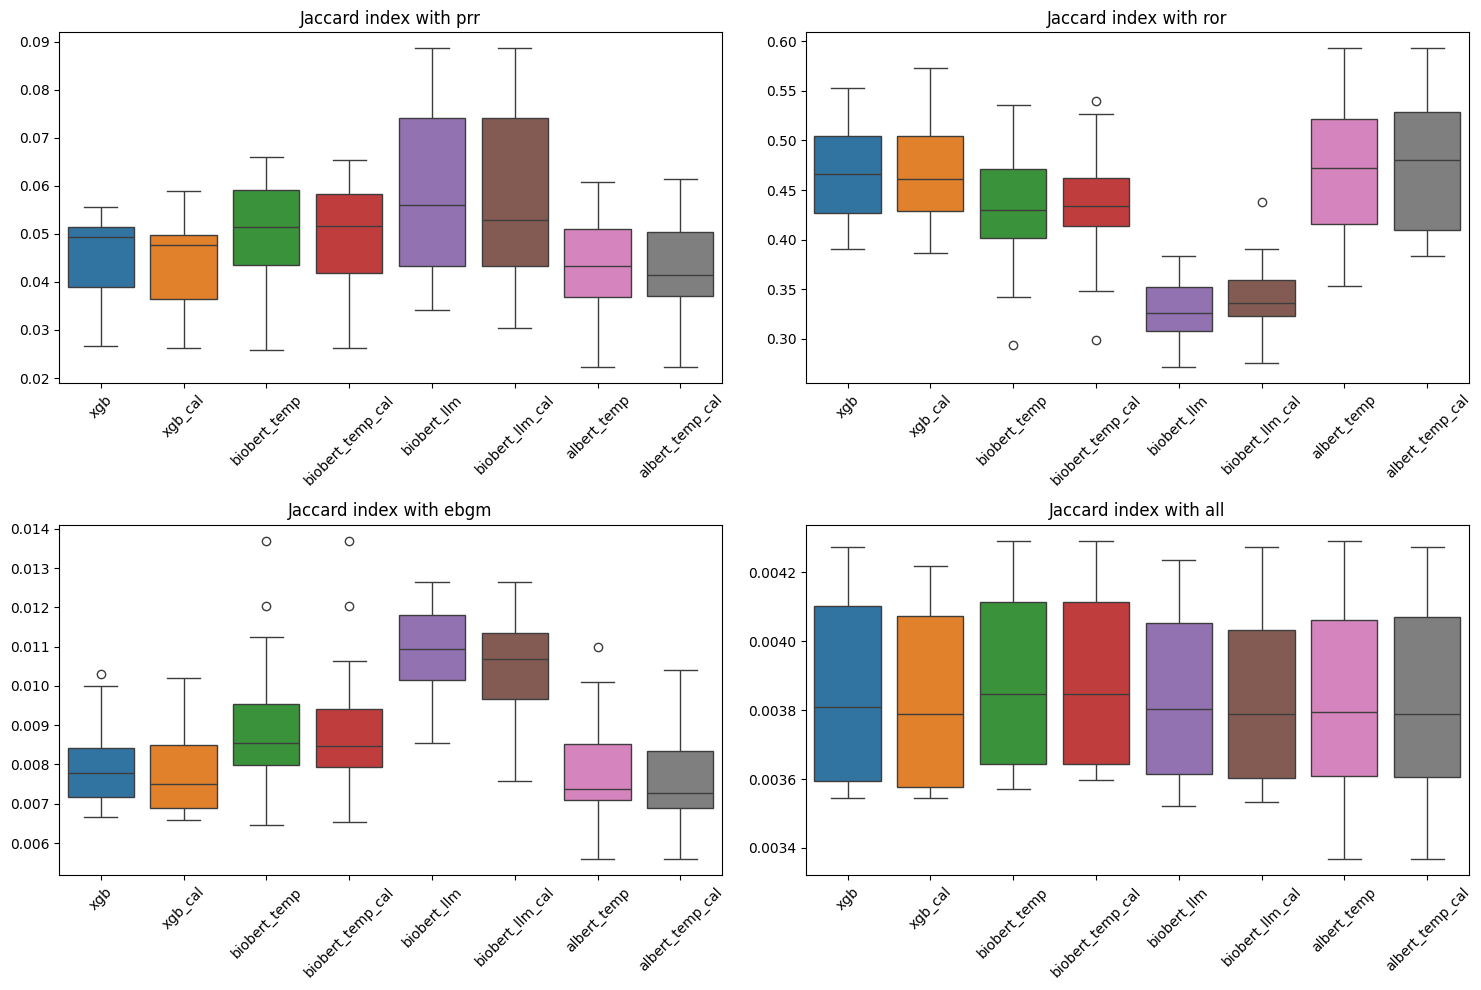

In [9]:
# put all four trad_methods plot into one figure
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
for i, trad in enumerate(trad_methods):
    ax = axs[i//2, i%2]

    df = pd.DataFrame({})
    for model in model_names:
        df[model] = jac_dict[model][trad]
    sns.boxplot(data=df, ax=ax)
    # rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_title(f"Jaccard index with {trad}")

plt.tight_layout()
plt.show()

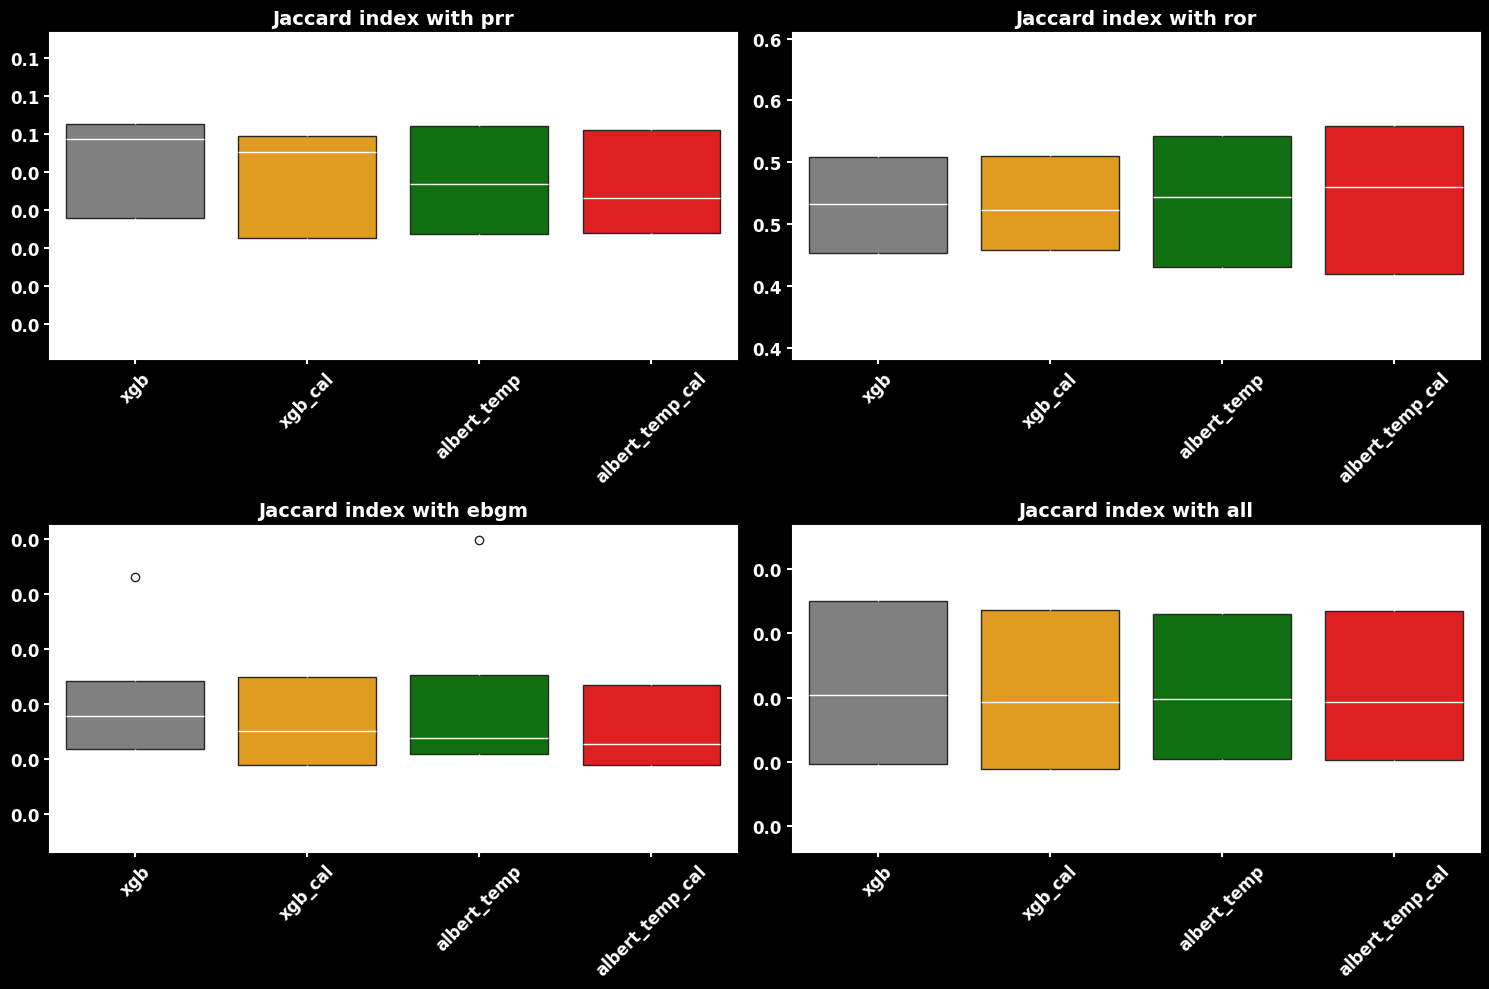

In [10]:
# put all four trad_methods plot into one figure
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
for i, trad in enumerate(trad_methods):
    ax = axs[i//2, i%2]

    df = pd.DataFrame({})
    for model in ["xgb", "xgb_cal", "albert_temp", "albert_temp_cal"]:
        df[model] = jac_dict[model][trad]
    sns.boxplot(data=df, ax=ax,
                palette = ["gray", "orange", "green", "red"])
    # rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontweight='bold', color='white', size=12)
    ax.set_title(f"Jaccard index with {trad}", fontsize=14, color='white', fontweight='bold')
        # Set box boundaries to white
    for box in ax.artists:
        box.set_edgecolor('white')
        box.set_linewidth(1.5)  # Optional: makes the white edges more visible
    
    # Customize whiskers, caps, and medians to white
    for line in ax.lines:
        line.set_color('white')
    
    # Customize axis appearance
    ax.spines['bottom'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['right'].set_color('white')
    
    ax.tick_params(labelcolor='white', labelsize=12, axis="both", colors='white', width=1.5)
    yticks = ax.get_yticks()
    ax.set_yticklabels([f'{y:.1f}' for y in yticks], fontweight='bold', color='white', size=12) 
fig.set_facecolor('black')
plt
plt.tight_layout()
plt.savefig(os.path.join(dirpath, "jaccard_trad_methods.png"), transparent=True)
plt.show()

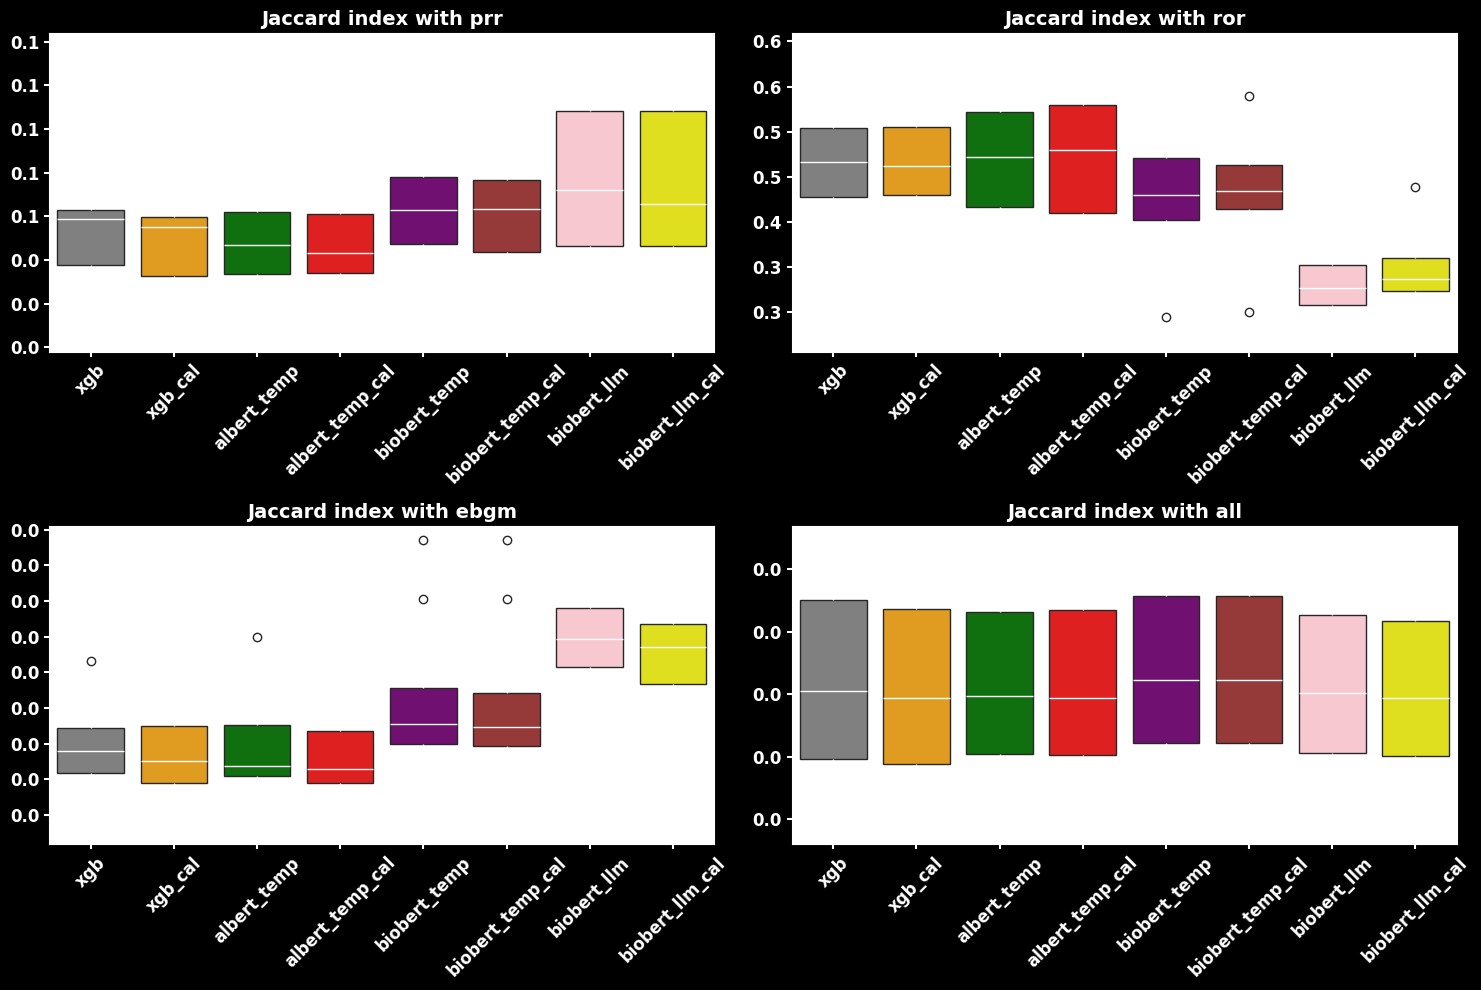

In [11]:
# put all four trad_methods plot into one figure
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
for i, trad in enumerate(trad_methods):
    ax = axs[i//2, i%2]

    df = pd.DataFrame({})
    for model in ["xgb", "xgb_cal", "albert_temp", "albert_temp_cal", 'biobert_temp', 'biobert_temp_cal', 'biobert_llm',
       'biobert_llm_cal']:
        df[model] = jac_dict[model][trad]
    sns.boxplot(data=df, ax=ax,
                palette = ['gray', 'orange', 'green', 'red', "purple", "brown", "pink", "yellow"])
    # rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45,fontweight='bold', color='white', size=12)
    ax.set_title(f"Jaccard index with {trad}", fontsize=14, color='white', fontweight='bold')
        # Set box boundaries to white
    for box in ax.artists:
        box.set_edgecolor('white')
        box.set_linewidth(1.5)  # Optional: makes the white edges more visible
    
    # Customize whiskers, caps, and medians to white
    for line in ax.lines:
        line.set_color('white')
    
    # Customize axis appearance
    ax.spines['bottom'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['right'].set_color('white')
    
    ax.tick_params(labelcolor='white', labelsize=12, axis="both", colors='white', width=1.5)
    yticks = ax.get_yticks()
    ax.set_yticklabels([f'{y:.1f}' for y in yticks], fontweight='bold', color='white', size=12) 
fig.set_facecolor('black')
plt
plt.tight_layout()
plt.savefig(os.path.join(dirpath, "jaccard_trad_methods_all.png"), transparent=True)
plt.show()